In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import pickle
from bayes_opt import BayesianOptimization
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from matplotlib import rcParams

In [2]:
# 前処理データの読み込み
train = pd.read_csv('train_balanced_pre.csv')

In [3]:
# 目的変数 '賃料' と説明変数を指定
X = train.drop(columns=['賃料'])  # 説明変数
y = train['賃料']  # 目的変数

In [4]:
# データを学習用とテスト用に分割（8:2）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# RMSEスコアの計算関数
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [6]:
# ベイズ最適化用の目的関数を定義
def xgb_evaluate(n_estimators, max_depth, learning_rate, subsample, colsample_bytree):
    # XGBoostモデルの初期化
    model = xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=int(n_estimators),
        max_depth=int(max_depth),
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        random_state=42,
        n_jobs=-1
    )
    # モデルを学習
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    # テストデータでの予測
    y_pred = model.predict(X_test)
    # RMSEを返す（最小化するためにマイナスにする）
    return -rmse(y_test, y_pred)

In [7]:
# パラメータの範囲を設定
param_bounds = {
    'n_estimators': (10, 300),         # 木の数
    'max_depth': (2, 10),              # 木の深さ
    'learning_rate': (0.001, 0.1),     # 学習率
    'subsample': (0.6, 1.0),           # サブサンプルの割合
    'colsample_bytree': (0.6, 1.0)     # 特徴量サンプルの割合
}

In [8]:
# Bayesian Optimizationの実行
optimizer = BayesianOptimization(
    f=xgb_evaluate,
    pbounds=param_bounds,
    random_state=42
)

In [9]:
# 最適化の開始（初期5回はランダム探索、最大10回探索）
optimizer.maximize(init_points=5, n_iter=10)

|   iter    |  target   | colsam... | learni... | max_depth | n_esti... | subsample |
-------------------------------------------------------------------------------------
| 1         | -9.274e+0 | 0.7498    | 0.09512   | 7.856     | 183.6     | 0.6624    |
| 2         | -4.67e+04 | 0.6624    | 0.00675   | 8.929     | 184.3     | 0.8832    |
| 3         | -1.779e+0 | 0.6082    | 0.09702   | 8.66      | 71.58     | 0.6727    |
| 4         | -3.088e+0 | 0.6734    | 0.03112   | 6.198     | 135.3     | 0.7165    |
| 5         | -4.79e+04 | 0.8447    | 0.01481   | 4.337     | 116.2     | 0.7824    |
| 6         | -2.131e+0 | 0.6124    | 0.07431   | 8.653     | 71.51     | 0.7071    |
| 7         | -8.881e+0 | 0.7779    | 0.1       | 7.512     | 183.4     | 0.6       |
| 8         | -1.29e+04 | 0.6478    | 0.1       | 7.317     | 184.0     | 0.6       |
| 9         | -1.791e+0 | 0.6       | 0.1       | 8.737     | 72.41     | 0.6       |
| 10        | -8.943e+0 | 1.0       | 0.1       | 7.91

In [10]:
# ベストパラメータ
print("Best parameters found: ", optimizer.max)

Best parameters found:  {'target': -8881.197548431473, 'params': {'colsample_bytree': 0.7778503288421091, 'learning_rate': 0.1, 'max_depth': 7.511734900094159, 'n_estimators': 183.38250988982438, 'subsample': 0.6}}


In [11]:
# 最適なハイパーパラメータを使ってモデルを再構築
best_params = optimizer.max['params']
best_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=int(best_params['n_estimators']),
    max_depth=int(best_params['max_depth']),
    learning_rate=best_params['learning_rate'],
    subsample=best_params['subsample'],
    colsample_bytree=best_params['colsample_bytree'],
    random_state=42,
    n_jobs=-1
)

In [12]:
# ベストモデルで学習（アーリーストッピング付き）
eval_set = [(X_train, y_train), (X_test, y_test)]
best_model.fit(X_train, y_train, eval_set=eval_set, eval_metric='rmse', early_stopping_rounds=10, verbose=True)

[0]	validation_0-rmse:93248.13271	validation_1-rmse:92799.91504
[1]	validation_0-rmse:86009.31812	validation_1-rmse:85924.75324
[2]	validation_0-rmse:78656.57759	validation_1-rmse:79030.75630
[3]	validation_0-rmse:73156.36347	validation_1-rmse:73924.07996
[4]	validation_0-rmse:68367.84005	validation_1-rmse:69509.77721
[5]	validation_0-rmse:62956.58771	validation_1-rmse:64449.26259
[6]	validation_0-rmse:58335.34169	validation_1-rmse:60225.90090
[7]	validation_0-rmse:54848.69883	validation_1-rmse:56907.00001
[8]	validation_0-rmse:52056.02480	validation_1-rmse:54365.99602
[9]	validation_0-rmse:48723.63187	validation_1-rmse:51373.76181
[10]	validation_0-rmse:45726.95923	validation_1-rmse:48682.44989
[11]	validation_0-rmse:43015.81249	validation_1-rmse:46069.37943
[12]	validation_0-rmse:40819.62839	validation_1-rmse:44109.72290
[13]	validation_0-rmse:39211.72433	validation_1-rmse:42562.09297
[14]	validation_0-rmse:37907.15563	validation_1-rmse:41395.93849
[15]	validation_0-rmse:36670.03421	

/home/whitesalena/python/pytorch/lib/python3.10/site-packages/xgboost/sklearn.py:889: UserWarning: `eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.
  warnings.warn(
/home/whitesalena/python/pytorch/lib/python3.10/site-packages/xgboost/sklearn.py:889: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


[19]	validation_0-rmse:32314.70206	validation_1-rmse:36094.78385
[20]	validation_0-rmse:31282.70375	validation_1-rmse:35123.48315
[21]	validation_0-rmse:29928.15070	validation_1-rmse:33440.53482
[22]	validation_0-rmse:29240.64731	validation_1-rmse:32850.14037
[23]	validation_0-rmse:28722.56915	validation_1-rmse:32269.12572
[24]	validation_0-rmse:28147.16715	validation_1-rmse:31770.52640
[25]	validation_0-rmse:27603.79270	validation_1-rmse:31249.93536
[26]	validation_0-rmse:27233.21780	validation_1-rmse:30927.86850
[27]	validation_0-rmse:26815.03870	validation_1-rmse:30505.08669
[28]	validation_0-rmse:26378.64885	validation_1-rmse:30047.49598
[29]	validation_0-rmse:26126.80352	validation_1-rmse:29796.47770
[30]	validation_0-rmse:25820.49001	validation_1-rmse:29486.10466
[31]	validation_0-rmse:25358.72483	validation_1-rmse:28878.72942
[32]	validation_0-rmse:25154.91142	validation_1-rmse:28676.66876
[33]	validation_0-rmse:24869.40683	validation_1-rmse:28350.74037
[34]	validation_0-rmse:24

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7778503288421091, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=183,
             n_jobs=-1, num_parallel_tree=None, random_state=42, ...)

In [13]:
# テストデータでの予測
y_pred = best_model.predict(X_test)

In [14]:
# テストデータでのRMSE評価
test_rmse = rmse(y_test, y_pred)
print(f"Test RMSE: {test_rmse}")

Test RMSE: 8881.197548431473


In [15]:
# 学習曲線のプロット
results = best_model.evals_result()

In [16]:
# トレーニングと検証データのRMSEを取得
epochs = len(results['validation_0']['rmse'])
x_axis = range(0, epochs)

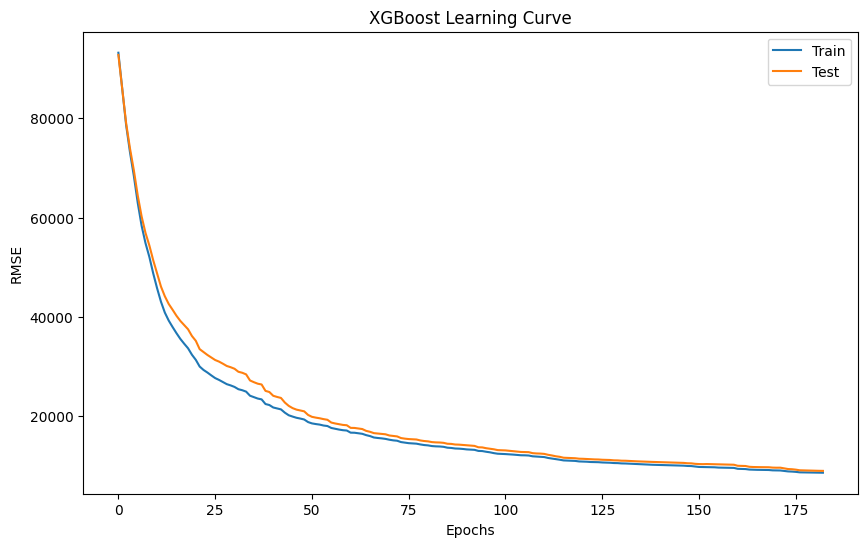

In [17]:
# 学習曲線のプロット
plt.figure(figsize=(10,6))
plt.plot(x_axis, results['validation_0']['rmse'], label='Train')
plt.plot(x_axis, results['validation_1']['rmse'], label='Test')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('RMSE')
plt.title('XGBoost Learning Curve')
plt.show()

In [18]:
# モデルの保存
with open("model.pickle", mode="wb") as fp:
    pickle.dump(best_model, fp)

In [19]:
# 日本語フォントを指定
rcParams['font.family'] = 'IPAexGothic'

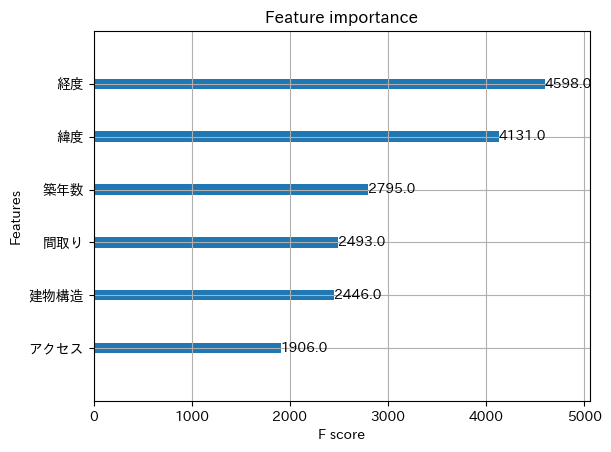

In [20]:
# 特徴量の重要度を表示
xgb.plot_importance(best_model)
plt.show()

In [21]:
# 特徴量重要度の取得
importance = best_model.feature_importances_

# 各特徴量とその重要度を確認する
for i, v in enumerate(importance):
    print(f"Feature: {i}, Score: {v:.5f}")

Feature: 0, Score: 0.08222
Feature: 1, Score: 0.29591
Feature: 2, Score: 0.14143
Feature: 3, Score: 0.10670
Feature: 4, Score: 0.25536
Feature: 5, Score: 0.11838


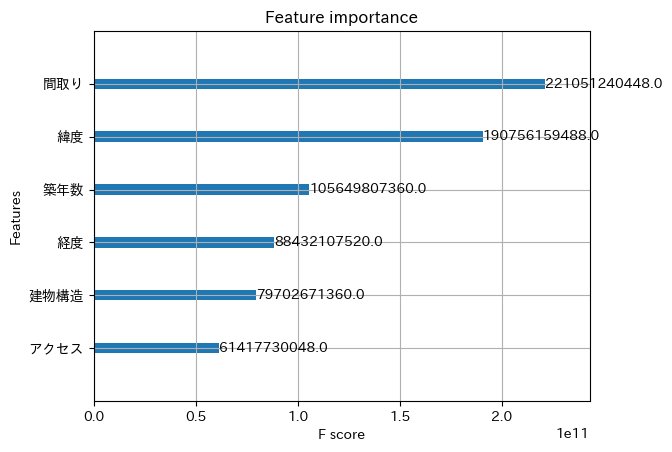

In [22]:
# gain: 分岐により得られた情報の平均量（モデルの精度に最も影響を与える特徴量）
xgb.plot_importance(best_model, importance_type='gain')  # 他に'weight', 'cover'が利用可能
plt.show()